In [ ]:
import os
import jax
from jax import numpy as np, tree as jtu, random as jr

import equinox as eqx
from kneed import KneeLocator
from dLux import utils as dlu
from optax import sgd, adam, linear_schedule

import amigo as amg
from amigo import plotting
import dorito as drt
from dorito.stats import disco_regularised_loss_fn

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

plt.style.use(['science',  'bright', 'no-latex'])
new_rcParams = {
    'image.cmap': 'inferno',
    'font.family': 'serif',
    'image.origin': 'lower',
    'figure.dpi': 300,
    'font.size': 8,
    'xtick.direction': 'out',
    'ytick.direction': 'out'
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps['inferno']
viridis = mpl.colormaps['viridis']
seismic = mpl.colormaps['seismic']
coolwarm = mpl.colormaps['coolwarm']

inferno.set_bad('k', 0.5)
viridis.set_bad('k', 0.5)
seismic.set_bad('k', 0.5)
coolwarm.set_bad('k', 0.5)

In [2]:
from frito.autoencoder.ae_utils import load_classes_from_file as lcf, run_svd
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
)
from frito.utils import normalize_image
from frito.simulate import inject_image

In [28]:
master_key = jr.key(0)
main_data_path = "_data"
autoencoder_data_path = os.path.join(main_data_path, "autoencoder")
main_trained_model_path = os.path.join(autoencoder_data_path, "trained_models")
main_svd_path = os.path.join(autoencoder_data_path, "svd")
training_data_path = os.path.join(autoencoder_data_path, "training_data")
emnist_path = os.path.join(training_data_path, "emnist.npz")
mnist_path = os.path.join(training_data_path, "mnist.npz")
ppd_51_path = os.path.join(training_data_path, "fake_intensity_PPDs_51x51.npz")

main_out_path = "_output"
main_model_struct_path = "src/frito/autoencoder/model_structures"

emnist_data = np.load(emnist_path)
test_emnist_data = np.clip(emnist_data["x_test"], min=1e-8)
# test_51x51_data = np.clip(
#     test_51x51_data / np.max(test_51x51_data, axis=(1, 2), keepdims=True),
#     min=1e-8,
# )
test_emnist_image = test_emnist_data[225]

disco_HD135344B_path = os.path.join(
    main_data_path, "jwst", "HD135344B", "disco", "cal_vis_HD135344B.npy"
)
disco_PDS70_path = os.path.join(
    main_data_path, "jwst", "PDS70", "disco", "bgmask_cal_vis_pds70.npy"
)
disco_PDS70 = np.load(disco_PDS70_path, allow_pickle=True).item()

In [29]:
model_key, master_key   = jr.split(master_key, 2)
model_type              = 'emnist'
i = 0
model_names = ["widest"]
model_name = model_names[i]
model_struct_path = os.path.join(
    main_model_struct_path, f"{model_name}_model.py"
)
trained_model_path = os.path.join(
    main_trained_model_path, model_type, f"emnist_{model_name}_best.eqx"
)
autoencoder_classes = lcf(model_struct_path)
autoencoder = autoencoder_classes["autoencoder"](key=model_key)
base_autoencoder = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)

print(f"Model: {model_name}")
print(f"Model Struct: {model_struct_path}")
print(f"Trained Model Path: {trained_model_path}")
print(f"Autoencoder Classes: {autoencoder_classes}")

Model: widest
Model Struct: src/frito/autoencoder/model_structures/widest_model.py
Trained Model Path: _data/autoencoder/trained_models/emnist/emnist_widest_best.eqx
Autoencoder Classes: {'autoencoder': <class 'widest_model.autoencoder'>, 'decoder': <class 'widest_model.decoder'>, 'encoder': <class 'widest_model.encoder'>}


SVD Path: _data/autoencoder/svd/emnist_model_widest_svd.npz


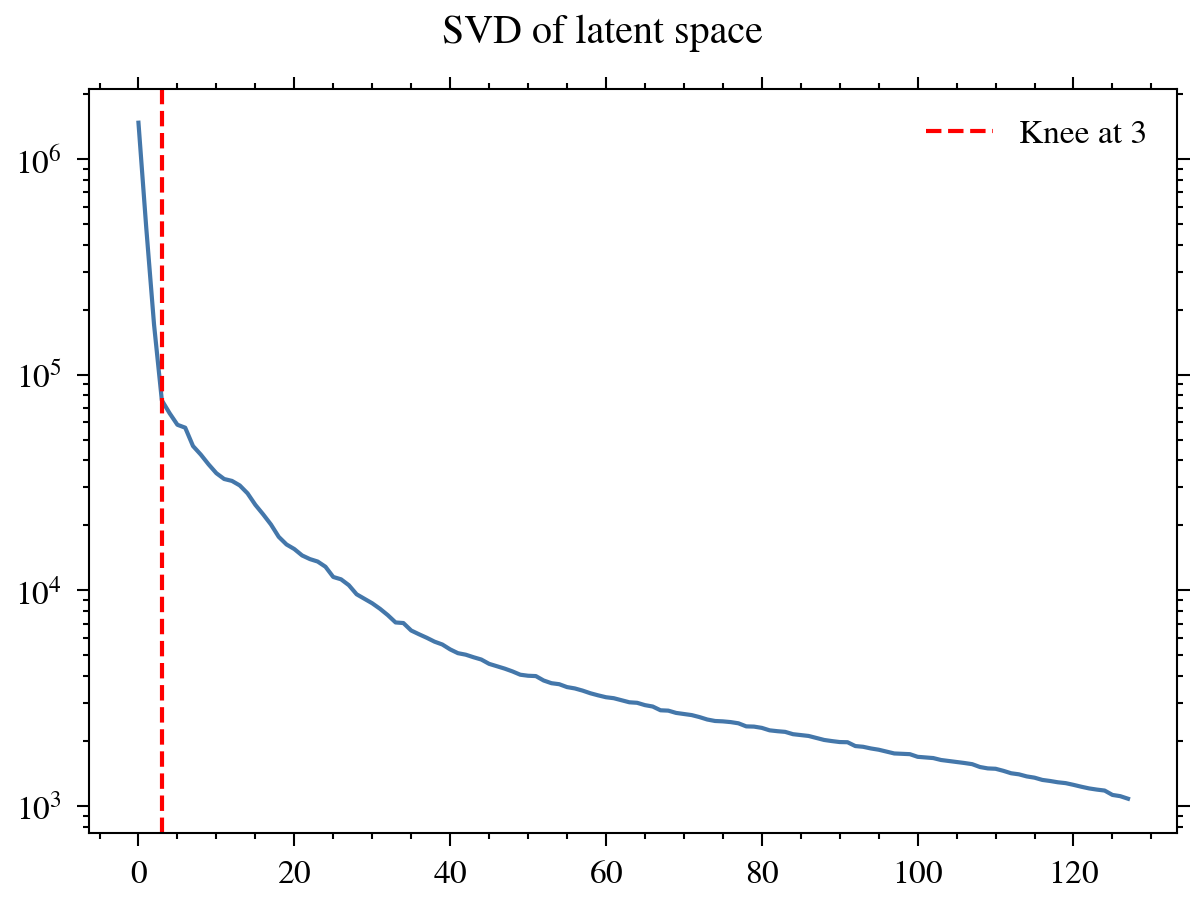

Knee at 3


In [30]:
svd_path = os.path.join(
    main_svd_path, f"{model_type}_model_{model_name}_svd.npz"
)
print(f"SVD Path: {svd_path}")
# run_svd(model_struct_path, trained_model_path, emnist_path, main_svd_path, f"{model_type}_model_{model_name}_svd.npz")
svd = np.load(svd_path)

k1 = KneeLocator(
    np.arange(len(svd["s"])),
    svd["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of latent space")
ax.plot(svd["s"], marker=",")
ax.axvline(k1.knee, color="r", linestyle="--", label=f"Knee at {k1.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"Knee at {k1.knee}")

In [31]:
def embed(X, knee, m, s, v):
    return (X - m[:knee]) @ v[:knee, :knee].T / np.sqrt(s[:knee] ** 2 / knee)


embed_layer = eqx.nn.Lambda(
    lambda z: embed(z, int(len(svd['s'])), svd["mean"], svd["s"], svd["v"])
)

norm_ae = eqx.tree_at(
    lambda m: m.modules[0].layers,
    base_autoencoder,
    base_autoencoder.modules[0].layers + [embed_layer],
)

def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s[:knee] ** 2 / knee)) @ v[:knee, :knee] + m[
        :knee
    ]
unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(len(svd['s'])), svd["mean"], svd["s"], svd["v"])
)


norm_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    norm_ae,
    [unembed_layer] + norm_ae.modules[1].layers
)

def sum2unity(X):
    return X / np.sum(X, axis=(1, 2), keepdims=True)


sum2unity_layer = eqx.nn.Lambda(lambda z: sum2unity(z))
norm_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    norm_ae,
    norm_ae.modules[1].layers + [sum2unity_layer],
)

encoder, decoder = norm_ae.modules

Text(0.5, 1.0, 'Autoencoded Simulated Disk')

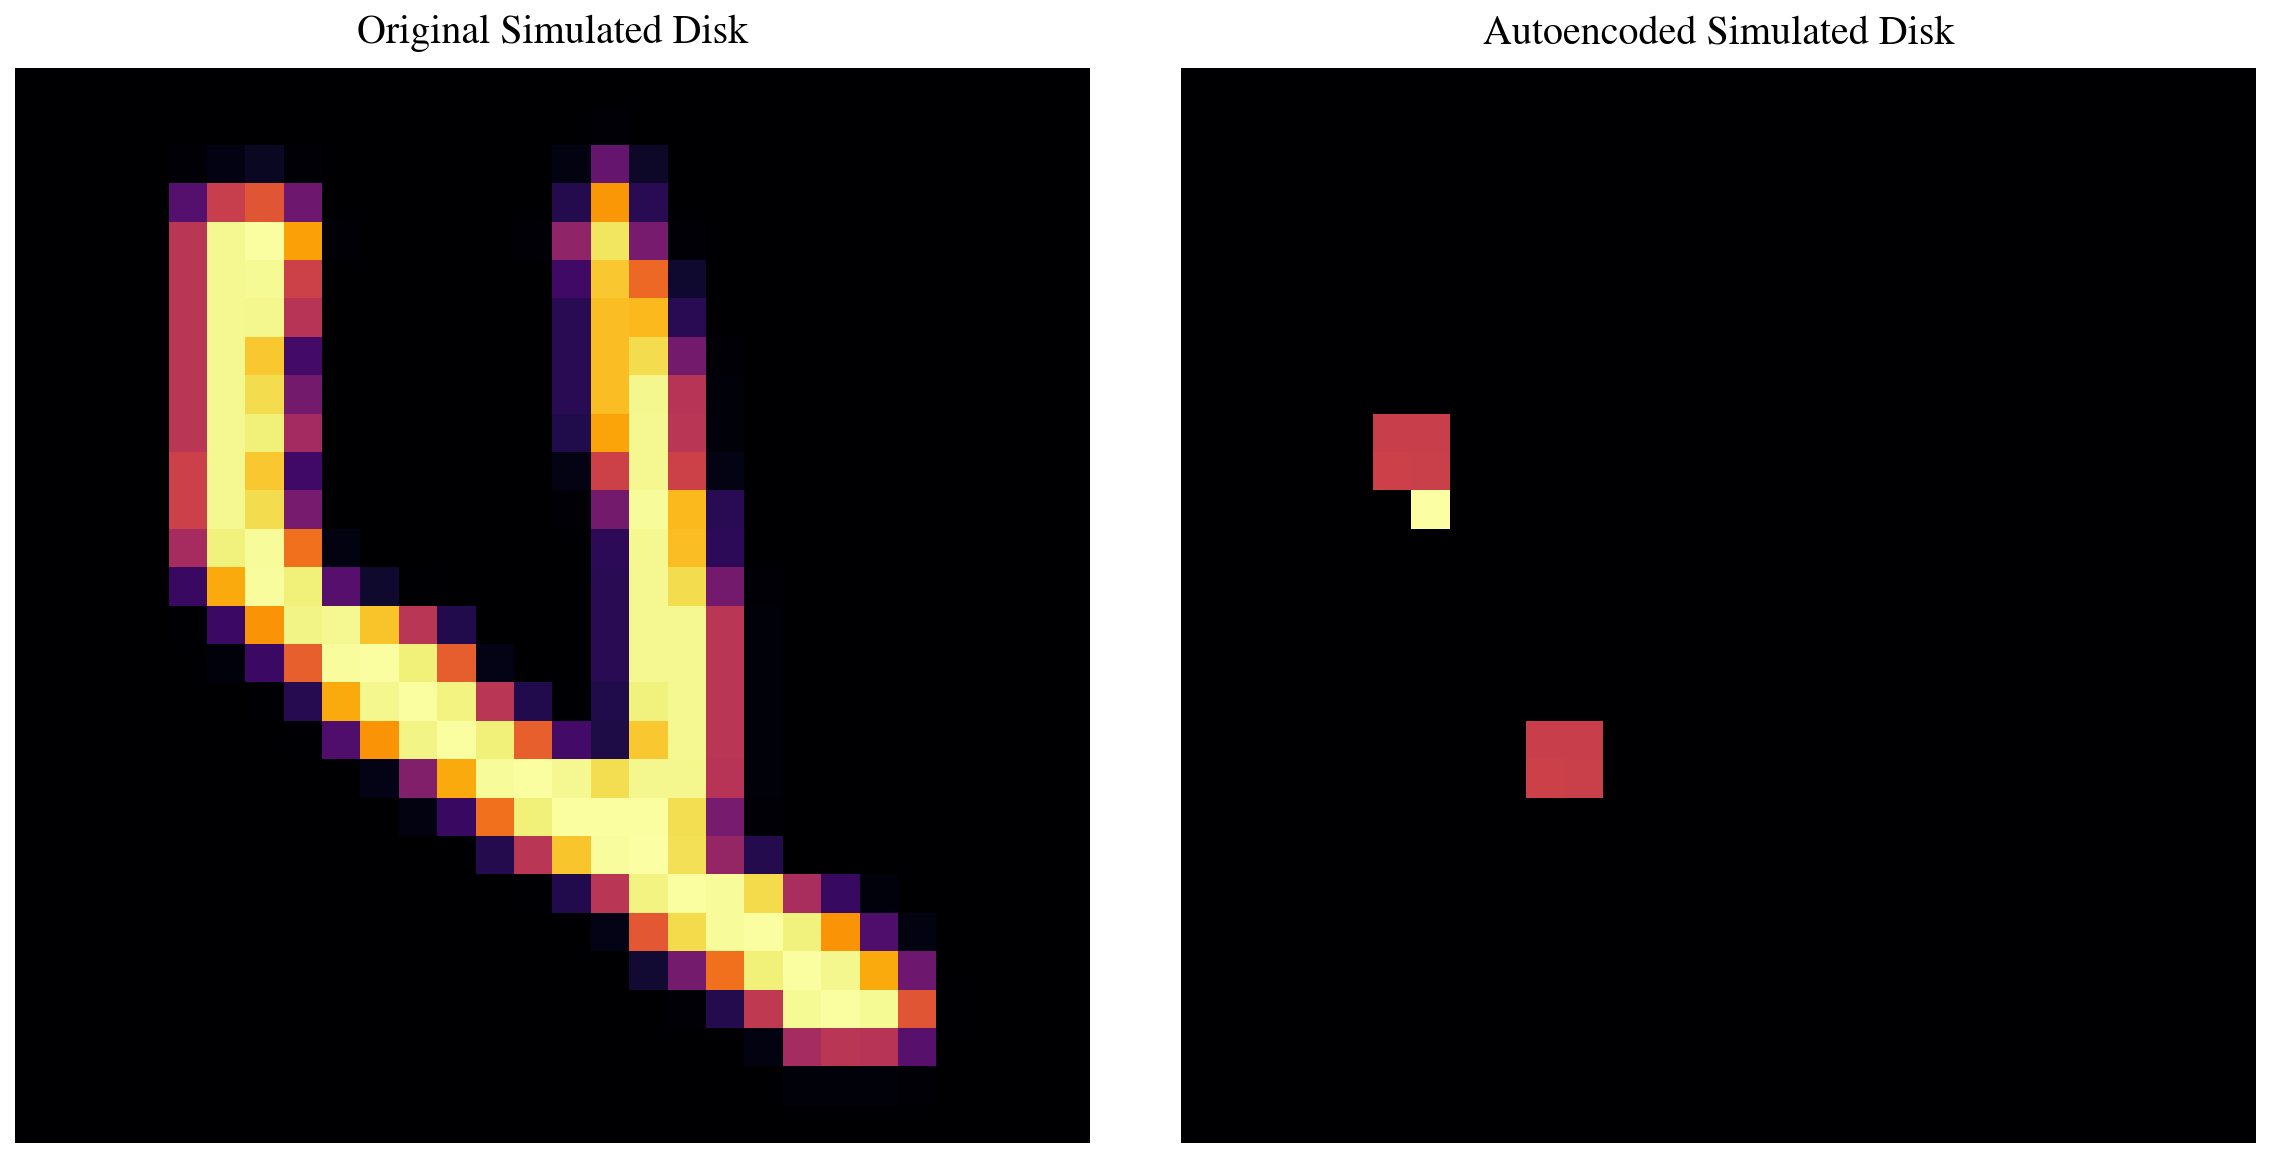

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), layout="tight")
ax[0].imshow(test_emnist_image)
ax[0].set_axis_off()
ax[0].set_title("Original Simulated Disk")
ax[1].imshow(decoder(encoder(test_emnist_image.reshape(1, 28, 28)))[0])
ax[1].set_axis_off()
ax[1].set_title("Autoencoded Simulated Disk")